# 🍎🍊🍌 Fruit Quality Grading
## Step 1: Feature Extraction + K-Means Labeling

This notebook extracts visual features from fresh fruit images and uses **K-Means clustering** to automatically assign quality grades (**A, B, C**) to each image — replacing the need for manual labeling.

### Pipeline
```
Fresh fruit images
       ↓
Extract features (Color → Texture → Shape)
       ↓
Normalize features (StandardScaler)
       ↓
K-Means clustering per fruit (k=3)
       ↓
Auto-assign Grade A / B / C
       ↓
Save labeled_dataset.csv  ← input for CNN training
```

### Fruits
- 🍎 Apple
- 🍊 Orange  
- 🍌 Banana

### Expected Dataset Structure (Kaggle Fresh & Rotten)
```
dataset/
├── train/
│   ├── freshapples/
│   ├── freshoranges/
│   └── freshbananas/
└── test/
    ├── freshapples/
    ├── freshoranges/
    └── freshbananas/
```

## 📦 1. Install Dependencies

In [1]:
!pip install opencv-python scikit-learn scikit-image pandas tqdm matplotlib -q

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.16.1 requires numpy<2.0.0,>=1.23.5; python_version <= "3.11", but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📚 2. Imports

In [3]:
import os
import shutil
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from skimage.feature import graycomatrix, graycoprops
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")
print("✅ All libraries imported successfully")

✅ All libraries imported successfully


## ⚙️ 3. Configuration

> **Edit `DATASET_ROOT`** to point to where you downloaded the Kaggle dataset.

In [14]:
# ─────────────────────────────────────────────
#  CONFIGURATION — edit these as needed
# ─────────────────────────────────────────────

DATASET_ROOT  = "dataset"    # ← path to your Kaggle dataset folder
OUTPUT_DIR    = "output"     # ← where results will be saved
IMAGE_SIZE    = (224, 224)   # resize all images before feature extraction
N_CLUSTERS    = 3            # number of quality grades (A, B, C)
N_SAMPLES     = 10           # sample images saved per cluster for inspection
RANDOM_STATE  = 42

# Apples can include red and green varieties. These color-identity features
# are excluded only for apple clustering so K-Means focuses more on quality
# signals such as blemishes, smoothness, brightness, and uniformity.
APPLE_EXCLUDED_CLUSTER_FEATURES = {
    "hue_mean",
    "r_mean",
    "g_mean",
    "b_mean",
}

# Fruit folder names in the dataset → clean label
FRUIT_FOLDERS = {
    "freshapples":  "apple",
    "freshoranges": "orange",
    "freshbanana": "banana",
}

# ── Manual grade override (optional) ──────────────────────────────
# After running the notebook, open output/cluster_samples/ and inspect
# the sample images. If the auto-assignment looks wrong, set the correct
# mapping here and re-run from Cell 7 onwards.
#
# Example:
# GRADE_OVERRIDE = {
#     "apple":  {0: "B", 1: "A", 2: "C"},
#     "orange": {0: "A", 1: "C", 2: "B"},
#     "banana": {0: "C", 1: "B", 2: "A"},
# }
GRADE_OVERRIDE = {}

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"✅ Config set — output will be saved to: {os.path.abspath(OUTPUT_DIR)}")

✅ Config set — output will be saved to: c:\Users\Rafael Po\Kuliah\Semester 6\DeepLearning\fruit-grading\output


## 🔬 4. Feature Extraction Functions

We extract **18 features** per image across 3 groups:

| Group | Features | Quality Signal |
|---|---|---|
| **Color** | Hue, Saturation, Brightness (mean & std), Color uniformity, RGB means | Vibrant, uniform color = higher grade |
| **Texture** | GLCM Contrast, Homogeneity, Energy, Correlation, Dissimilarity | Smooth surface = higher grade |
| **Shape** | Blemish ratio, Edge density, Roundness | Fewer marks, rounder = higher grade |

In [5]:
def load_image(path: str):
    """Load and resize an image. Returns None if loading fails."""
    img = cv2.imread(path)
    if img is None:
        return None
    return cv2.resize(img, IMAGE_SIZE)


def extract_color_features(img_bgr: np.ndarray) -> dict:
    """Extract HSV and RGB color features."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    h, s, v = hsv[:,:,0], hsv[:,:,1], hsv[:,:,2]
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    return {
        "hue_mean":         np.mean(h),
        "hue_std":          np.std(h),
        "sat_mean":         np.mean(s),
        "sat_std":          np.std(s),
        "val_mean":         np.mean(v),  # brightness
        "val_std":          np.std(v),
        "color_uniformity": 1.0 / (np.std(s) + 1e-5),
        "r_mean":           np.mean(r),
        "g_mean":           np.mean(g),
        "b_mean":           np.mean(b),
    }


def extract_texture_features(img_bgr: np.ndarray) -> dict:
    """Extract GLCM texture features."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray_small = cv2.resize(gray, (64, 64))
    glcm = graycomatrix(
        gray_small,
        distances=[1, 3],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=256, symmetric=True, normed=True,
    )
    return {
        "texture_contrast":      graycoprops(glcm, "contrast").mean(),
        "texture_dissimilarity": graycoprops(glcm, "dissimilarity").mean(),
        "texture_homogeneity":   graycoprops(glcm, "homogeneity").mean(),
        "texture_energy":        graycoprops(glcm, "energy").mean(),
        "texture_correlation":   graycoprops(glcm, "correlation").mean(),
    }


def extract_shape_features(img_bgr: np.ndarray) -> dict:
    """Extract blemish, edge density, and roundness features."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

    # Blemish ratio: dark pixels relative to mean brightness
    blemish_ratio = np.sum(gray < np.mean(gray) * 0.5) / gray.size

    # Edge density via Canny
    edges = cv2.Canny(gray, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size

    # Roundness via largest contour
    _, thresh = cv2.threshold(gray, 30, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    roundness = 0.0
    if contours:
        largest = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(largest)
        perimeter = cv2.arcLength(largest, True)
        if perimeter > 0:
            roundness = (4 * np.pi * area) / (perimeter ** 2)

    return {
        "blemish_ratio": blemish_ratio,
        "edge_density":  edge_density,
        "roundness":     roundness,
    }


def extract_all_features(img_bgr: np.ndarray) -> dict:
    """Combine all feature groups into one feature vector."""
    feats = {}
    feats.update(extract_color_features(img_bgr))
    feats.update(extract_texture_features(img_bgr))
    feats.update(extract_shape_features(img_bgr))
    return feats


print("✅ Feature extraction functions defined")

✅ Feature extraction functions defined


## 🛠️ 5. Helper Functions (Data Collection, Grading, Visualization)

In [6]:
def collect_image_paths(dataset_root: str) -> dict:
    """Scan dataset folder and collect image paths per fruit type."""
    root = Path(dataset_root)
    fruit_paths = {fruit: [] for fruit in FRUIT_FOLDERS.values()}

    for split in ["train", "test"]:
        for folder_name, fruit_label in FRUIT_FOLDERS.items():
            folder = root / split / folder_name
            if not folder.exists():
                folder = root / folder_name  # try without split subfolder
            if folder.exists():
                paths = (list(folder.glob("*.jpg")) +
                         list(folder.glob("*.jpeg")) +
                         list(folder.glob("*.png")))
                fruit_paths[fruit_label].extend([str(p) for p in paths])

    return fruit_paths


def auto_assign_grades(cluster_centers: np.ndarray, feature_names: list) -> dict:
    """
    Rank clusters by a quality score to assign A / B / C.

    Quality score weights:
    - Brightness (val_mean)       +0.25  → brighter = fresher
    - Saturation (sat_mean)       +0.20  → more color = riper
    - Color uniformity            +0.20  → uniform = consistent quality
    - Texture homogeneity         +0.15  → smooth surface = higher grade
    - Blemish ratio               -0.10  → fewer blemishes = better
    - Edge density                -0.10  → smoother surface = better
    """
    idx = {name: i for i, name in enumerate(feature_names)}
    scores = []
    for center in cluster_centers:
        score = (
            + 0.25 * center[idx.get("val_mean", 0)]           / 255.0
            + 0.20 * center[idx.get("sat_mean", 0)]           / 255.0
            + 0.20 * center[idx.get("color_uniformity", 0)]   / 10.0
            + 0.15 * center[idx.get("texture_homogeneity", 0)]
            - 0.10 * center[idx.get("blemish_ratio", 0)]
            - 0.10 * center[idx.get("edge_density", 0)]
        )
        scores.append(score)

    ranked = np.argsort(scores)[::-1]  # highest score = Grade A
    return {int(cluster_id): ["A", "B", "C"][rank] for rank, cluster_id in enumerate(ranked)}


def save_cluster_samples(image_paths, cluster_labels, fruit, n_samples=10):
    """Copy sample images from each cluster for manual inspection."""
    for cluster_id in range(N_CLUSTERS):
        out_dir = Path(OUTPUT_DIR) / "cluster_samples" / f"{fruit}_cluster_{cluster_id}"
        out_dir.mkdir(parents=True, exist_ok=True)
        indices = np.where(cluster_labels == cluster_id)[0]
        sampled = np.random.choice(indices, size=min(n_samples, len(indices)), replace=False)
        for i, idx in enumerate(sampled):
            src = image_paths[idx]
            dst = out_dir / f"sample_{i:02d}{Path(src).suffix}"
            shutil.copy2(src, dst)


def plot_pca_clusters(X_scaled, cluster_labels, grade_map, fruit):
    """Reduce to 2D with PCA and plot the quality clusters."""
    pca    = PCA(n_components=2, random_state=RANDOM_STATE)
    coords = pca.fit_transform(X_scaled)

    colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}
    point_colors = [colors[grade_map[lbl]] for lbl in cluster_labels]

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(coords[:, 0], coords[:, 1], c=point_colors, alpha=0.5, s=15, edgecolors="none")

    patches = [mpatches.Patch(color=colors[g], label=f"Grade {g}") for g in ["A", "B", "C"]]
    ax.legend(handles=patches, fontsize=12)

    var = pca.explained_variance_ratio_
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}% variance)", fontsize=11)
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}% variance)", fontsize=11)
    ax.set_title(f"{fruit.capitalize()} — K-Means Quality Clusters (PCA 2D)", fontsize=13, fontweight="bold")
    ax.grid(True, linestyle="--", alpha=0.4)

    plots_dir = Path(OUTPUT_DIR) / "plots"
    plots_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(plots_dir / f"{fruit}_pca.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"  📊 Plot saved → output/plots/{fruit}_pca.png")


print("✅ Helper functions defined")

✅ Helper functions defined


## 📁 6. Collect Image Paths

In [7]:
fruit_paths = collect_image_paths(DATASET_ROOT)

print("Images found per fruit:")
for fruit, paths in fruit_paths.items():
    status = "✅" if paths else "❌ NOT FOUND"
    print(f"  {fruit:8s} → {len(paths):,} images  {status}")

if all(len(v) == 0 for v in fruit_paths.values()):
    print(f"\n⚠️  No images found. Check that DATASET_ROOT = '{DATASET_ROOT}' is correct.")
    print(f"   Full path: {os.path.abspath(DATASET_ROOT)}")

Images found per fruit:
  apple    → 2,088 images  ✅
  orange   → 1,854 images  ✅
  banana   → 1,962 images  ✅


## 🔍 7. Extract Features from All Images

This cell loops through every fruit image and extracts the 18 visual features.  
It may take a few minutes depending on dataset size.

In [8]:
fruit_feature_data = {}   # stores DataFrame of features per fruit
fruit_valid_paths  = {}   # stores valid image paths per fruit

for fruit, paths in fruit_paths.items():
    if not paths:
        print(f"⚠️  Skipping {fruit} — no images found.")
        continue

    print(f"\n🔍 Extracting features: {fruit.upper()} ({len(paths):,} images)...")

    feature_rows = []
    valid_paths  = []

    for path in tqdm(paths, desc=f"  {fruit}"):
        img = load_image(path)
        if img is None:
            continue
        feats = extract_all_features(img)
        feats["image_path"] = path
        feats["fruit"]      = fruit
        feature_rows.append(feats)
        valid_paths.append(path)

    df = pd.DataFrame(feature_rows)
    fruit_feature_data[fruit] = df
    fruit_valid_paths[fruit]  = valid_paths
    print(f"  ✅ {len(valid_paths):,} images processed | {len(df.columns)-2} features extracted")

# Save raw features
all_features_df = pd.concat(fruit_feature_data.values(), ignore_index=True)
all_features_df.to_csv(Path(OUTPUT_DIR) / "kmeans_features.csv", index=False)
print(f"\n💾 Raw features saved → output/kmeans_features.csv")


🔍 Extracting features: APPLE (2,088 images)...


  apple:   0%|          | 0/2088 [00:00<?, ?it/s]

  ✅ 2,088 images processed | 18 features extracted

🔍 Extracting features: ORANGE (1,854 images)...


  orange:   0%|          | 0/1854 [00:00<?, ?it/s]

  ✅ 1,854 images processed | 18 features extracted

🔍 Extracting features: BANANA (1,962 images)...


  banana:   0%|          | 0/1962 [00:00<?, ?it/s]

  ✅ 1,962 images processed | 18 features extracted

💾 Raw features saved → output/kmeans_features.csv


## 👀 8. Preview Extracted Features

In [9]:
# Show a sample of extracted features for one fruit
sample_fruit = list(fruit_feature_data.keys())[0]
feature_cols = [c for c in fruit_feature_data[sample_fruit].columns if c not in ("image_path", "fruit")]

print(f"Feature preview — {sample_fruit.upper()} (first 5 rows):\n")
fruit_feature_data[sample_fruit][feature_cols].head()

Feature preview — APPLE (first 5 rows):



,hue_mean,hue_std,sat_mean,sat_std,val_mean,val_std,color_uniformity,r_mean,g_mean,b_mean,texture_contrast,texture_dissimilarity,texture_homogeneity,texture_energy,texture_correlation,blemish_ratio,edge_density,roundness
0,8.106166,27.727673,90.152527,89.957367,184.160858,77.211891,0.011116,182.189072,132.970703,125.929626,3348.668108,24.678135,0.382134,0.262201,0.786743,0.269113,0.051279,0.814457
1,21.428513,18.089674,77.103897,76.625565,184.677750,76.682236,0.013050,175.118378,184.516129,132.251419,2110.719853,17.489170,0.388536,0.251722,0.806567,0.125817,0.025450,0.813432
2,106.864456,85.415604,102.754303,86.027061,175.331528,71.791153,0.011624,175.326691,109.010506,114.305847,2790.506473,23.394900,0.289655,0.140714,0.786736,0.194316,0.053691,0.815688
3,62.812382,83.331177,93.183617,83.530251,192.801239,71.599297,0.011972,192.792358,125.297974,124.789680,2707.460992,22.607687,0.310212,0.182253,0.777777,0.127710,0.071787,0.813647
4,26.789501,55.529331,77.814651,78.664330,193.541168,75.989555,0.012712,189.275085,149.185440,136.752792,2936.531474,24.045652,0.358794,0.246296,0.774328,0.164979,0.064314,0.815360


## 📊 9. Feature Distribution (Key Quality Features)

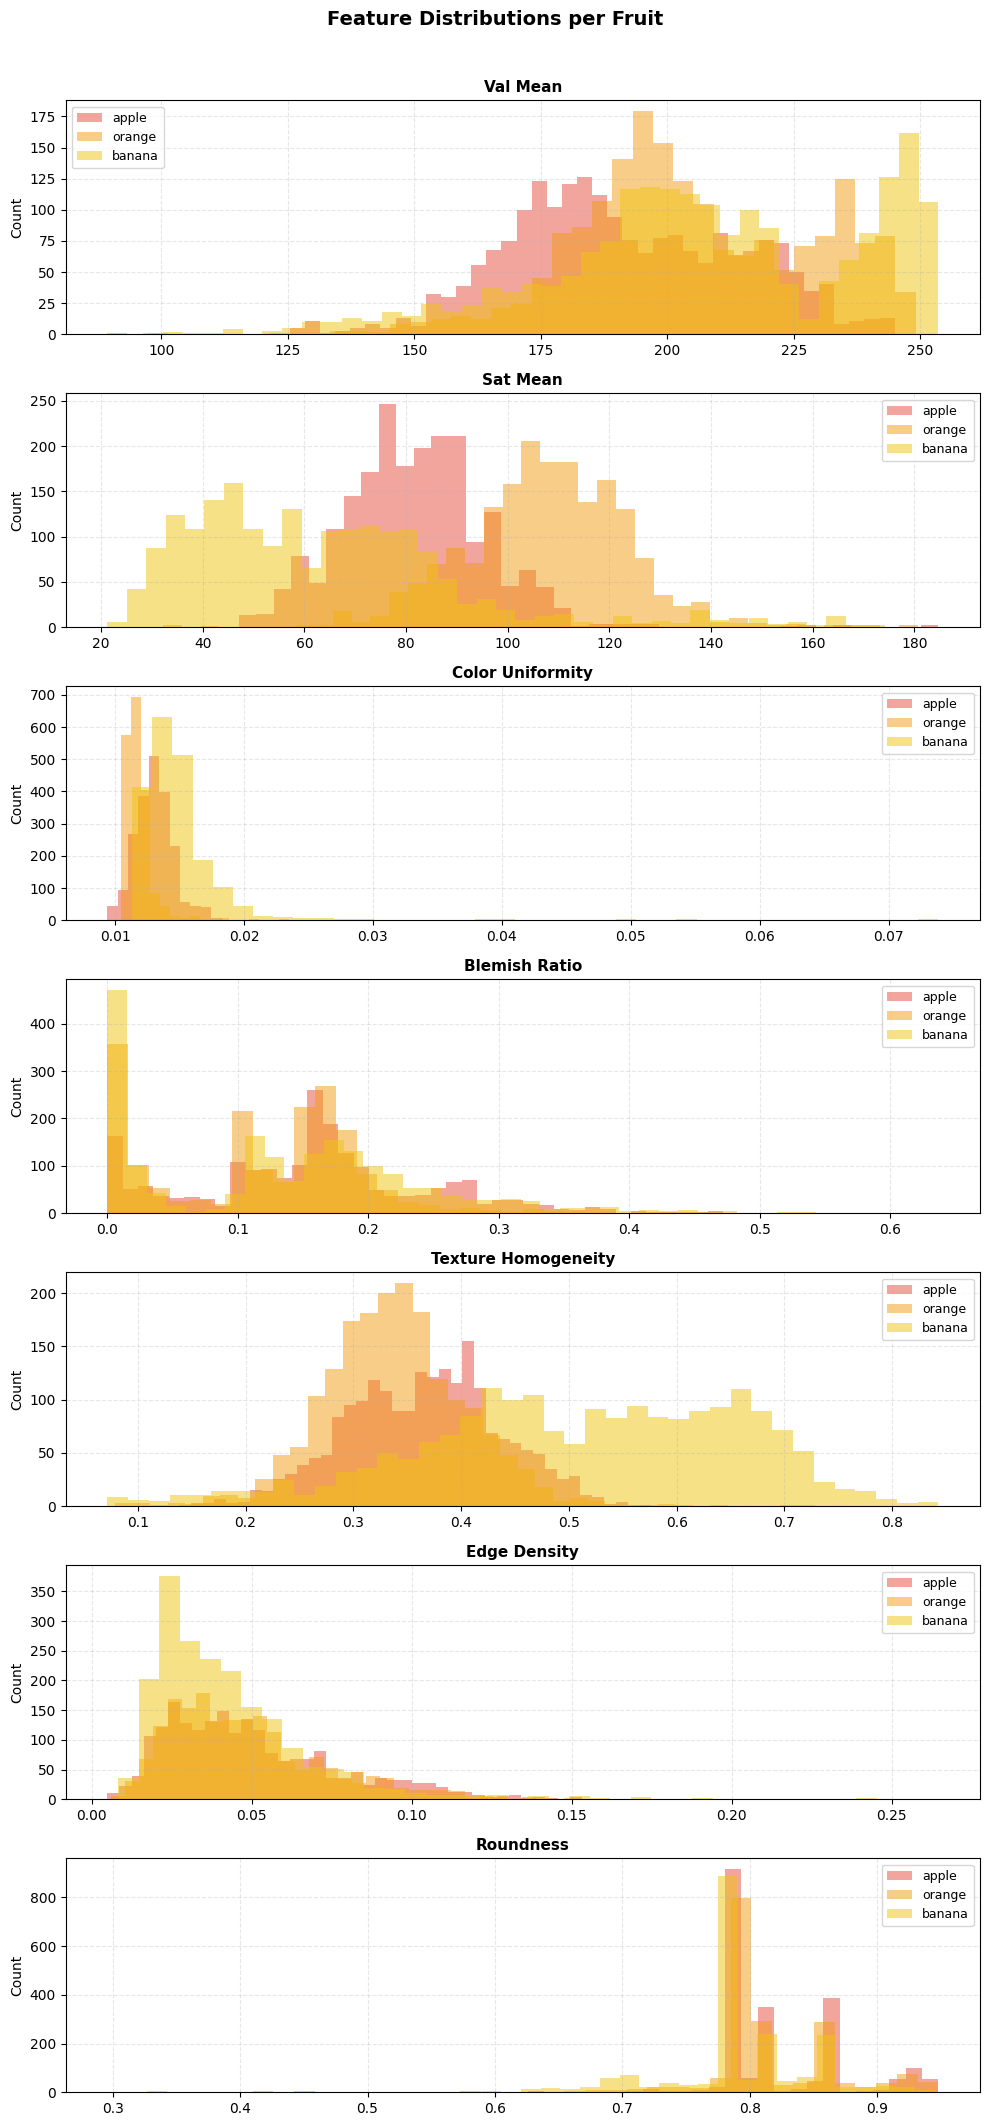

In [11]:
key_features = ["val_mean", "sat_mean", "color_uniformity", "blemish_ratio",
                "texture_homogeneity", "edge_density", "roundness"]

fig, axes = plt.subplots(len(key_features), 1, figsize=(10, 3 * len(key_features)))
fruit_colors = {"apple": "#e74c3c", "orange": "#f39c12", "banana": "#f1c40f"}

for i, feat in enumerate(key_features):
    ax = axes[i]
    for fruit, df in fruit_feature_data.items():
        if feat in df.columns:
            ax.hist(df[feat], bins=40, alpha=0.5, label=fruit, color=fruit_colors.get(fruit))
    ax.set_title(feat.replace("_", " ").title(), fontsize=11, fontweight="bold")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.3)

plt.suptitle("Feature Distributions per Fruit", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "plots" / "feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## 🤖 10. K-Means Clustering (per Fruit)

Each fruit is clustered **independently** so K-Means finds quality variation *within* that fruit type, not differences between fruit types.

In [15]:
all_records    = []   # will become the final labeled CSV
fruit_clusters = {}   # stores cluster labels per fruit

for fruit, df in fruit_feature_data.items():
    print(f"\n{'─'*50}")
    print(f"🍎 Clustering: {fruit.upper()}")
    print(f"{'─'*50}")

    excluded_cols = {"image_path", "fruit"}
    if fruit == "apple":
        excluded_cols |= APPLE_EXCLUDED_CLUSTER_FEATURES

    feature_cols  = [c for c in df.columns if c not in excluded_cols]
    if fruit == "apple":
        removed = sorted(APPLE_EXCLUDED_CLUSTER_FEATURES & set(df.columns))
        print(f"  Apple color-identity features excluded from clustering: {removed}")
    X             = df[feature_cols].values
    valid_paths   = fruit_valid_paths[fruit]

    # Normalize
    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # K-Means
    kmeans        = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=20, max_iter=500)
    cluster_labels = kmeans.fit_predict(X_scaled)

    # Grade assignment
    if fruit in GRADE_OVERRIDE:
        grade_map = GRADE_OVERRIDE[fruit]
        print(f"  ℹ️  Using manual override: {grade_map}")
    else:
        grade_map = auto_assign_grades(kmeans.cluster_centers_, feature_cols)
        print(f"  🤖 Auto-assigned grades:   {grade_map}")

    # Print distribution
    unique, counts = np.unique(cluster_labels, return_counts=True)
    print("  Cluster distribution:")
    for cid, cnt in zip(unique, counts):
        grade = grade_map[int(cid)]
        pct   = cnt / len(cluster_labels) * 100
        bar   = "█" * int(pct / 2)
        print(f"    Cluster {cid} → Grade {grade}: {cnt:>5,} images ({pct:5.1f}%)  {bar}")

    # Save cluster samples for manual inspection
    save_cluster_samples(valid_paths, cluster_labels, fruit, N_SAMPLES)

    # Store for PCA plot
    fruit_clusters[fruit] = (X_scaled, cluster_labels, grade_map, feature_cols)

    # Collect labeled records
    for i, path in enumerate(valid_paths):
        cid   = int(cluster_labels[i])
        grade = grade_map[cid]
        all_records.append({
            "image_path": path,
            "fruit":      fruit,
            "cluster_id": cid,
            "grade":      grade,
            "label":      f"{fruit}_{grade}",
        })

print("\n✅ Clustering complete for all fruits")


──────────────────────────────────────────────────
🍎 Clustering: APPLE
──────────────────────────────────────────────────
  🤖 Auto-assigned grades:   {2: 'A', 1: 'B', 0: 'C'}
  Cluster distribution:
    Cluster 0 → Grade C:   687 images ( 32.9%)  ████████████████
    Cluster 1 → Grade B:   671 images ( 32.1%)  ████████████████
    Cluster 2 → Grade A:   730 images ( 35.0%)  █████████████████

──────────────────────────────────────────────────
🍎 Clustering: ORANGE
──────────────────────────────────────────────────
  🤖 Auto-assigned grades:   {1: 'A', 0: 'B', 2: 'C'}
  Cluster distribution:
    Cluster 0 → Grade B: 1,173 images ( 63.3%)  ███████████████████████████████
    Cluster 1 → Grade A:   558 images ( 30.1%)  ███████████████
    Cluster 2 → Grade C:   123 images (  6.6%)  ███

──────────────────────────────────────────────────
🍎 Clustering: BANANA
──────────────────────────────────────────────────
  🤖 Auto-assigned grades:   {2: 'A', 0: 'B', 1: 'C'}
  Cluster distribution:
    Cl

## Clustering Validation

This cell checks whether the K-Means clusters are reasonably separated using Silhouette score, Davies-Bouldin index, and elbow curves.

In [ ]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

validation_records = []
elbow_results = {}

for fruit, (X_scaled, cluster_labels, grade_map, feature_cols) in fruit_clusters.items():
    n_clusters_found = len(np.unique(cluster_labels))

    if n_clusters_found > 1:
        silhouette = silhouette_score(X_scaled, cluster_labels)
        db_index = davies_bouldin_score(X_scaled, cluster_labels)
    else:
        silhouette = np.nan
        db_index = np.nan

    # Practical thresholds for exploratory pseudo-labeling, not strict proof.
    silhouette_pass = silhouette >= 0.20
    db_pass = db_index <= 2.00
    overall_pass = silhouette_pass and db_pass

    validation_records.append({
        "fruit": fruit,
        "features_used": len(feature_cols),
        "silhouette_score": silhouette,
        "davies_bouldin_index": db_index,
        "silhouette_status": "PASS" if silhouette_pass else "CHECK",
        "db_status": "PASS" if db_pass else "CHECK",
        "overall_status": "PASS" if overall_pass else "CHECK",
    })

    inertias = []
    k_values = range(2, min(8, len(X_scaled) - 1) + 1)
    for k in k_values:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20, max_iter=500)
        km.fit(X_scaled)
        inertias.append(km.inertia_)

    elbow_results[fruit] = (list(k_values), inertias)

validation_df = pd.DataFrame(validation_records)
display(validation_df.style.format({
    "silhouette_score": "{:.3f}",
    "davies_bouldin_index": "{:.3f}",
}).background_gradient(subset=["silhouette_score"], cmap="Greens")
  .background_gradient(subset=["davies_bouldin_index"], cmap="Reds_r"))

fig, ax = plt.subplots(figsize=(8, 5))
for fruit, (k_values, inertias) in elbow_results.items():
    ax.plot(k_values, inertias, marker="o", linewidth=2, label=fruit.capitalize())

ax.axvline(N_CLUSTERS, color="black", linestyle="--", alpha=0.5, label=f"Selected k={N_CLUSTERS}")
ax.set_title("Elbow Plot: K-Means Inertia by Fruit", fontsize=13, fontweight="bold")
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend()

plots_dir = Path(OUTPUT_DIR) / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(plots_dir / "clustering_validation_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

print("Validation guide:")
print("- Higher Silhouette is better; >= 0.20 is acceptable for exploratory image pseudo-labeling.")
print("- Lower Davies-Bouldin is better; <= 2.00 is acceptable here.")
print("- If a fruit is CHECK, inspect cluster samples before using its labels for CNN training.")


## 📈 11. PCA Cluster Visualizations

These 2D plots show how well K-Means separated the quality clusters. Well-separated clusters = reliable grade labels.


📊 PCA plot: APPLE


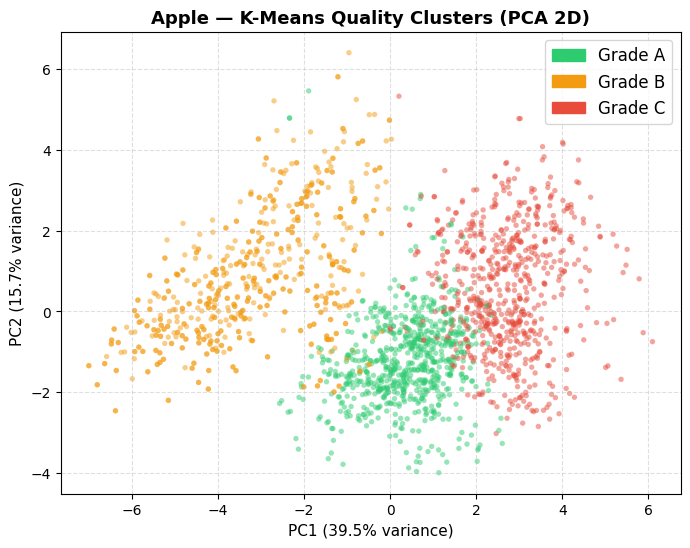

  📊 Plot saved → output/plots/apple_pca.png

📊 PCA plot: ORANGE


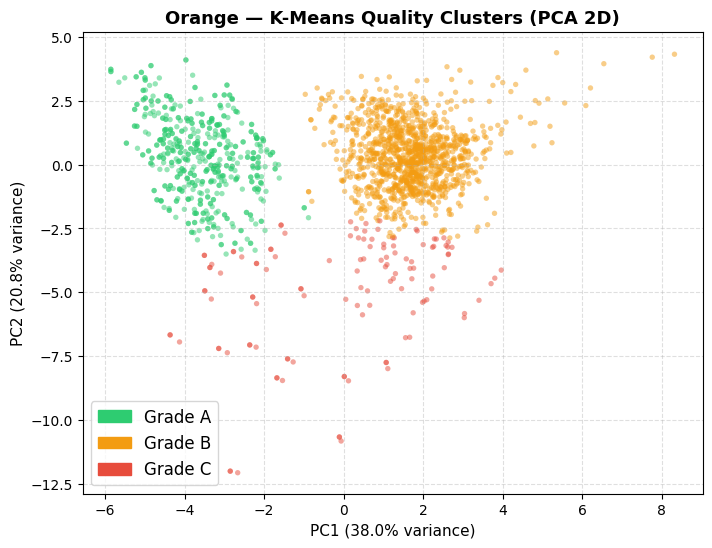

  📊 Plot saved → output/plots/orange_pca.png

📊 PCA plot: BANANA


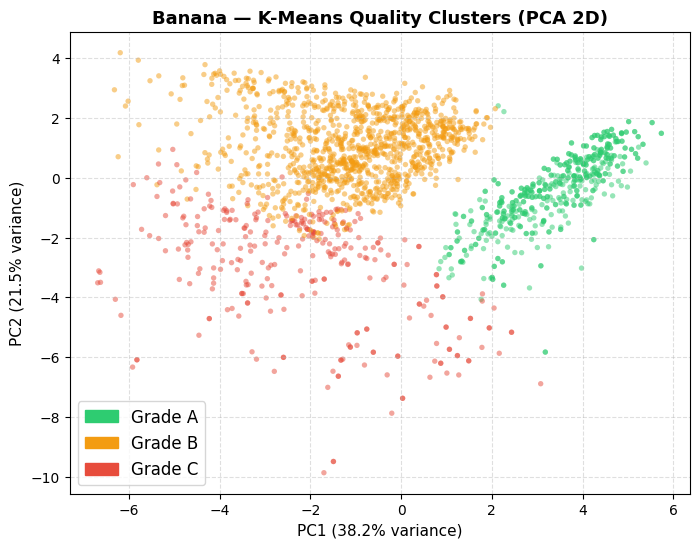

  📊 Plot saved → output/plots/banana_pca.png


In [16]:
for fruit, (X_scaled, cluster_labels, grade_map, _) in fruit_clusters.items():
    print(f"\n📊 PCA plot: {fruit.upper()}")
    plot_pca_clusters(X_scaled, cluster_labels, grade_map, fruit)

## 🖼️ 12. Visual Cluster Inspection

**This is the most important manual step.**

Look at the sample images below for each cluster and verify:
- **Grade A** → vibrant color, smooth surface, no marks
- **Grade B** → slightly dull or minor imperfections  
- **Grade C** → dull color, visible marks, irregular shape

If the grading looks wrong → update `GRADE_OVERRIDE` in Cell 3 and re-run from Cell 10.

In [ ]:
def show_cluster_samples(fruit, grade_map, n_show=5):
    """Display sample images from each cluster inline."""
    fig, axes = plt.subplots(N_CLUSTERS, n_show, figsize=(3 * n_show, 3.5 * N_CLUSTERS))
    grade_colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}

    for row, cluster_id in enumerate(range(N_CLUSTERS)):
        grade      = grade_map[cluster_id]
        sample_dir = Path(OUTPUT_DIR) / "cluster_samples" / f"{fruit}_cluster_{cluster_id}"
        images     = list(sample_dir.glob("*.jpg")) + list(sample_dir.glob("*.png"))[:n_show]

        for col in range(n_show):
            ax = axes[row, col]
            ax.axis("off")
            if col < len(images):
                img = cv2.imread(str(images[col]))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                ax.imshow(img)
                if col == 0:
                    ax.set_title(f"Grade {grade}", fontsize=13, fontweight="bold",
                                 color=grade_colors[grade], pad=8)

    plt.suptitle(f"{fruit.capitalize()} — Cluster Samples (verify grades below)",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig(Path(OUTPUT_DIR) / "plots" / f"{fruit}_cluster_samples.png",
                dpi=120, bbox_inches="tight")
    plt.show()


for fruit, (_, _, grade_map, _) in fruit_clusters.items():
    print(f"\n{'='*50}")
    print(f"  {fruit.upper()} — Visual Grade Check")
    print(f"{'='*50}")
    show_cluster_samples(fruit, grade_map)

## 💾 13. Save Labeled Dataset

In [ ]:
df_labeled = pd.DataFrame(all_records)

labeled_csv = Path(OUTPUT_DIR) / "labeled_dataset.csv"
df_labeled.to_csv(labeled_csv, index=False)

print(f"✅ Labeled dataset saved → {labeled_csv}")
print(f"   Total images: {len(df_labeled):,}\n")
print("Grade distribution:")
dist = df_labeled["label"].value_counts().sort_index()
for label, count in dist.items():
    bar = "█" * (count // 50)
    print(f"  {label:12s}  {count:>5,}  {bar}")

## 👀 14. Preview Labeled Dataset

In [ ]:
print(f"Shape: {df_labeled.shape}")
print(f"Columns: {list(df_labeled.columns)}\n")
df_labeled.head(10)

## 📊 15. Grade Distribution Chart

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Chart 1: Per fruit per grade ──
fruits = df_labeled["fruit"].unique()
grades = ["A", "B", "C"]
x      = np.arange(len(fruits))
width  = 0.25
colors = {"A": "#2ecc71", "B": "#f39c12", "C": "#e74c3c"}

for i, grade in enumerate(grades):
    counts = [len(df_labeled[(df_labeled["fruit"] == f) & (df_labeled["grade"] == grade)]) for f in fruits]
    axes[0].bar(x + i * width, counts, width, label=f"Grade {grade}", color=colors[grade], edgecolor="white")

axes[0].set_xticks(x + width)
axes[0].set_xticklabels([f.capitalize() for f in fruits], fontsize=12)
axes[0].set_title("Images per Fruit per Grade", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Number of Images")
axes[0].legend(fontsize=11)
axes[0].grid(True, axis="y", linestyle="--", alpha=0.4)

# ── Chart 2: Overall grade distribution ──
overall = df_labeled["grade"].value_counts().sort_index()
axes[1].bar(overall.index, overall.values,
            color=[colors[g] for g in overall.index], edgecolor="white", width=0.5)
for i, (grade, cnt) in enumerate(overall.items()):
    axes[1].text(i, cnt + 20, str(cnt), ha="center", fontsize=12, fontweight="bold")
axes[1].set_title("Overall Grade Distribution", fontsize=13, fontweight="bold")
axes[1].set_ylabel("Number of Images")
axes[1].set_xlabel("Grade")
axes[1].grid(True, axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(Path(OUTPUT_DIR) / "plots" / "grade_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("📊 Chart saved → output/plots/grade_distribution.png")

## ✅ 16. Summary & Next Steps

In [ ]:
print("=" * 60)
print("  STEP 1 COMPLETE — Feature Extraction + K-Means Labeling")
print("=" * 60)
print("Output saved to output/labeled_dataset.csv")
print(f"Total images  : {len(df_labeled):,}")
print(f"Fruits        : {', '.join(df_labeled['fruit'].unique())}")
print(f"Grades        : A, B, C")
print(f"Output labels : {', '.join(sorted(df_labeled['label'].unique()))}")
print("")
print("Before moving to CNN training:")
print("  1. Open output/cluster_samples/ and verify the grade assignments")
print("  2. If grades look wrong, update GRADE_OVERRIDE in Cell 3 and re-run from Cell 10")
print("  3. Once satisfied, use labeled_dataset.csv as input for the CNN")
print("")
print("Next: Step 2 - CNN Training (EfficientNetB0)")